# Build LogBB DL model.

This notebook shows how to build an DL model to predict LogBB. I plan to use this in a mechanistic model.

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINEConv, global_mean_pool, global_add_pool
from torch_geometric.data import Data, Batch

from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, rdPartialCharges
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold

import itertools
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

import pathlib
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#verify Cuda is actually working

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version (runtime):", torch.version.cuda)

print("Torch CUDA libraries loaded:")
for lib in torch.cuda._CudaBase.__module__.split(":"):
    print(lib)

Torch version: 2.8.0+cu128
CUDA available: True
CUDA version (runtime): 12.8
Torch CUDA libraries loaded:
torch.cuda


## Setup.

In [2]:
readout = 'log_bb'

In [3]:
# define paths
HERE = Path(pathlib.Path.cwd())
DATA = HERE / f"data_{readout}"
DATA.mkdir(parents=True, exist_ok=True)

In [4]:
# Load chembl data

df = pd.read_csv(f'{DATA}/{readout}_merged.csv',index_col=None)
df.head(5)

,Unnamed: 0,compound_id,smiles,log_bb
0,0,1_ZHU,CCCCC(C)C,0.86
1,1,2_ZHU,C=C,0.31
2,2,3_ZHU,C=COC=C,0.13
3,3,4_ZHU,CCC(C)N1CCN(CC1)C2=CC=C(I)C=C2,1.38
4,4,5_ZHU,CN1N(C2=CC=CC=C2)C(=O)C(=C1C)F,-0.05


In [5]:
len(df)

9246

In [8]:
# Remove NaN LogBB and SMILES.
df = df[
    df['log_bb'].notna() &
    # np.isfinite(df['log_bb']) &
    df['smiles'].notna()
]
len(df)

2497

Is the dataset balanced?

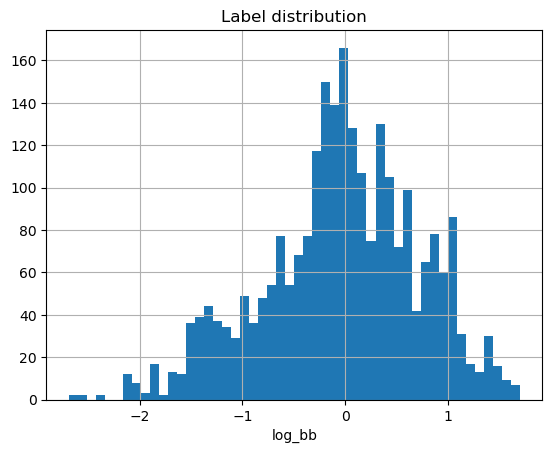

In [9]:
plt.hist(df['log_bb'], bins=50)
plt.xlabel("log_bb")
plt.title("Label distribution")
plt.grid(True)
plt.savefig("_images/sample_balance.png", dpi=300)
plt.show()

The dataset is clearly unbalanced (centred on low f_u, which is expected) - need to take a balanced sample.

In [10]:
# def stratified_balanced_sampling(df, label_col='standard_value', n_bins=20, max_samples_per_bin=500, random_state=42):
#     """
#     Stratified sampling to balance dataset by label distribution.

#     Args:
#         df (pd.DataFrame): DataFrame containing labelled data.
#         label_col (str): Name of the label column (e.g., 'pIC50').
#         n_bins (int): Number of bins to discretize the label.
#         max_samples_per_bin (int): Maximum number of samples to keep per bin.
#         random_state (int): Random seed for reproducibility.

#     Returns:
#         pd.DataFrame: Balanced DataFrame sampled from input.
#     """
#     np.random.seed(random_state)
    
#     # Create bins
#     bins = np.linspace(df[label_col].min(), df[label_col].max(), n_bins + 1)
#     df['bin'] = pd.cut(df[label_col], bins=bins, include_lowest=True, labels=False)

#     balanced_indices = []

#     for bin_id in range(n_bins):
#         bin_indices = df[df['bin'] == bin_id].index.values
#         n_samples = len(bin_indices)

#         if n_samples == 0:
#             continue
        
#         if n_samples > max_samples_per_bin:
#             chosen = np.random.choice(bin_indices, max_samples_per_bin, replace=False)
#         else:
#             chosen = np.random.choice(bin_indices, max_samples_per_bin, replace=True)

#         balanced_indices.extend(chosen)

#     # Create balanced dataset
#     balanced_df = df.loc[balanced_indices].reset_index(drop=True)

#     balanced_df = balanced_df.drop(columns=['bin'])

#     return balanced_df

In [11]:
# # Take a balanced sample before generating datasets for training
# balanced_df = stratified_balanced_sampling(df, label_col='log_bb', n_bins=20, max_samples_per_bin=500)

In [12]:
# # Is the dataset now balanced?

# plt.hist(balanced_df['log_bb'], bins=20)
# plt.xlabel("f_u")
# plt.title("Balanced Label Distribution")
# plt.grid(True)
# plt.show()

In [13]:
smiles_list = df['smiles'].tolist()
log_bb_values = df['log_bb'].tolist()

Pytorch geometric fix

In [14]:
# Here we define our own data structure for Pytorch Geometric to use in the model.
# Why? In the functions below, PyG's Batch.from_data_list tries to automatically 
# concatenate all descriptors and layers and gets the feature vector size wrong unless instructed not to. 
# (1D vector of 288 instead of 2D vector odf 32 x 9 chemical features)  
# global_features should be stacked (batched), not concatenated - the __cat_dim__ method controls that.

class MoleculeData(Data):
    def __inc__(self, key, value, *args, **kwargs):
        return super().__inc__(key, value)

    def __cat_dim__(self, key, value, *args, **kwargs):
        if key == 'global_features':
            return None  # do not concatenate along any dimension
        return super().__cat_dim__(key, value)


In [15]:
def safe_value(val):
    try:
        if np.isnan(val) or np.isinf(val):
            return 0.0
        return val
    except:
        return 0.0

## Featurisation step.

In [ ]:
from rdkit.Chem.rdchem import ChiralType

# helpers

def safe_value(x):
    try:
        if np.isnan(x) or np.isinf(x):
            return 0.0
        return float(x)
    except:
        return 0.0


def one_hot_encoding(x, allowable_set):
    if x not in allowable_set:
        x = allowable_set[-1]
    return [int(x == s) for s in allowable_set]


# ==========================================================
# Periodic table info
# ==========================================================

electronegativity_dict = {
    1: 2.20, 6: 2.55, 7: 3.04, 8: 3.44, 9: 3.98, 15: 2.19,
    16: 2.58, 17: 3.16, 35: 2.96, 53: 2.66,
}

metals = {
    3, 4, 11, 12, 13, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28,
    29, 30, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48,
    49, 55, 56, 57, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81,
    82, 83, 87, 88, 89, 104, 105, 106, 107, 108, 109, 110,
    111, 112, 113, 114, 115, 116
}


# ==========================================================
# Atom features
# ==========================================================

def get_atom_features(atom, mol=None):
    pt = Chem.GetPeriodicTable()
    features = []

    # --- Basic atom type & hybridization
    features += one_hot_encoding(atom.GetSymbol(),
                                ['C', 'N', 'O', 'F', 'P', 'S', 'Cl', 'Br', 'I', 'H',
                                 'B', 'Si', 'Se', 'As', 'Al', 'Zn', 'Cu', 'Ni', 'Fe', 'other'])

    features += one_hot_encoding(atom.GetHybridization(),
                                [Chem.rdchem.HybridizationType.SP,
                                 Chem.rdchem.HybridizationType.SP2,
                                 Chem.rdchem.HybridizationType.SP3,
                                 Chem.rdchem.HybridizationType.SP3D,
                                 Chem.rdchem.HybridizationType.SP3D2,
                                 Chem.rdchem.HybridizationType.UNSPECIFIED])

    # --- Local atomic environment
    features += [
        atom.GetDegree(),
        atom.GetFormalCharge(),
        atom.GetNumRadicalElectrons(),
        int(atom.GetIsAromatic())
    ]

    # --- Aromatic neighbors
    neigh_aromatic = sum(1 for n in atom.GetNeighbors() if n.GetIsAromatic())
    features += [neigh_aromatic / max(1, atom.GetDegree())]

    # --- Ring membership (sizes 3–6)
    ring_info = mol.GetRingInfo() if mol is not None else None
    if ring_info:
        for size in [3, 4, 5, 6]:
            features += [int(ring_info.IsAtomInRingOfSize(atom.GetIdx(), size))]
    else:
        features += [0, 0, 0, 0]

    # --- Physical/chemical constants (normalized)
    atomic_num = atom.GetAtomicNum()
    features += [
        pt.GetAtomicWeight(atomic_num) / 150,                 # normalized mass
        pt.GetRvdw(atomic_num) / 2.5,
        electronegativity_dict.get(atomic_num, 2.5) / 4.0,
        pt.GetNOuterElecs(atomic_num) / 8.0,
        1.0 if atomic_num in metals else 0.0,
        atom.GetTotalNumHs(includeNeighbors=True) / 4.0
    ]

    # --- Implicit hydrogens count (new)
    features.append(atom.GetNumImplicitHs())

    # --- Chirality one-hot encoding (new)
    chiral_tag = atom.GetChiralTag()
    chiral_one_hot = one_hot_encoding(chiral_tag, [
        ChiralType.CHI_UNSPECIFIED,
        ChiralType.CHI_TETRAHEDRAL_CW,
        ChiralType.CHI_TETRAHEDRAL_CCW,
        ChiralType.CHI_OTHER
    ])
    features += chiral_one_hot

    # --- Gasteiger charge (approximate partial charge)
    if mol is not None:
        try:
            charge = float(atom.GetProp('_GasteigerCharge'))
            charge = safe_value(charge)
        except:
            charge = 0.0
        features += [charge]
    else:
        features += [0.0]

    return np.array(features, dtype=np.float32)


# ==========================================================
# Bond features
# ==========================================================

def get_bond_features(bond, mol=None):
    i, j = bond.GetBeginAtom(), bond.GetEndAtom()
    bond_type = bond.GetBondType()

    # --- Basic bond types & conjugation
    features = [
        int(bond_type == Chem.rdchem.BondType.SINGLE),
        int(bond_type == Chem.rdchem.BondType.DOUBLE),
        int(bond_type == Chem.rdchem.BondType.TRIPLE),
        int(bond_type == Chem.rdchem.BondType.AROMATIC),
        int(bond.GetIsConjugated()),
        int(bond.IsInRing()),
    ]

    # --- Stereo and bond order
    features += [
        int(bond.GetStereo() != Chem.rdchem.BondStereo.STEREONONE),
        bond.GetBondTypeAsDouble() / 3.0
    ]

    # --- Electronegativity difference
    en_diff = abs(electronegativity_dict.get(i.GetAtomicNum(), 2.5) -
                  electronegativity_dict.get(j.GetAtomicNum(), 2.5))
    features += [en_diff / 4.0]

    # --- Is bond both aromatic and conjugated (new)
    features.append(int(bond.GetIsConjugated() and bond_type == Chem.rdchem.BondType.AROMATIC))

    # --- Sum of degrees of connected atoms (new)
    deg_sum = i.GetDegree() + j.GetDegree()
    features.append(deg_sum / 20)  # normalized by 20 as an example max degree

    # --- Bond ring size (new)
    if mol is not None:
        ring_info = mol.GetRingInfo()
        if ring_info.IsBondInRing(bond.GetIdx()):
            ring_sizes = ring_info.BondRings()[bond.GetIdx()]
            smallest_ring_size = min(len(ring) for ring in ring_sizes)
        else:
            smallest_ring_size = 0
        features.append(smallest_ring_size / 6)  # normalize by max ring size 6
    else:
        features.append(0)

    # --- Bond length (if 3D coords available, new)
    if mol is not None and mol.GetNumConformers() > 0:
        pos = mol.GetConformer().GetPositions()
        bond_length = np.linalg.norm(pos[bond.GetBeginAtomIdx()] - pos[bond.GetEndAtomIdx()])
        features.append(bond_length / 1.5)  # normalize by ~1.5 Å typical bond length
    else:
        features.append(0)

    return np.array(features, dtype=np.float32)


# ==========================================================
# Global molecular descriptors
# ==========================================================

descriptor_functions = [
    Descriptors.MolWt,
    Descriptors.MolLogP,
    Descriptors.NumHDonors,
    Descriptors.NumHAcceptors,
    Descriptors.TPSA,
    Descriptors.FractionCSP3,
    Descriptors.HeavyAtomCount,
    Descriptors.NumRotatableBonds,
    Descriptors.RingCount,
    rdMolDescriptors.CalcNumAmideBonds,
    rdMolDescriptors.CalcLabuteASA,
    rdMolDescriptors.CalcKappa1,
    rdMolDescriptors.CalcChi0n,
    rdMolDescriptors.CalcChi1n,
    lambda mol: rdMolDescriptors.CalcCrippenDescriptors(mol)[0],  # logP
    lambda mol: rdMolDescriptors.CalcCrippenDescriptors(mol)[1],  # MR
    rdMolDescriptors.CalcLabuteASA,
    # rdMolDescriptors.CalcChi0n, rdMolDescriptors.CalcChi1n,
    # rdMolDescriptors.CalcChi0v, rdMolDescriptors.CalcChi1v
]



## Convert Featurised molecules into graph for the model.

In [133]:
def mol_to_graph(smiles: str, label: float = None):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    try:
        rdPartialCharges.ComputeGasteigerCharges(mol)
    except:
        pass

    # --- Atom features
    atom_features = [get_atom_features(atom, mol) for atom in mol.GetAtoms()]
    x = torch.tensor(atom_features, dtype=torch.float)

    # --- Bonds / edges
    edge_index, edge_attr = [], []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        bfeat = get_bond_features(bond)
        edge_index += [[i, j], [j, i]]
        edge_attr += [bfeat, bfeat]

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    # --- Global descriptors
    global_features = []
    for func in descriptor_functions:
        try:
            val = safe_value(func(mol))
        except:
            val = 0.0
        global_features.append(val)
    global_features = torch.tensor(global_features, dtype=torch.float32)

    # --- Package into data object
    data = MoleculeData(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        global_features=global_features
    )

    if label is not None:
        data.y = torch.tensor([label], dtype=torch.float)

    data.smiles = smiles
    return data


Data loader code.

In [134]:
# We have to tell the DataLoader which features to expect.

def compute_global_features(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        # fallback vector of zeros if mol fails
        return torch.zeros(len(descriptor_functions), dtype=torch.float)
    feats = [fn(mol) for fn in descriptor_functions]
    return torch.tensor(feats, dtype=torch.float)

In [135]:
def custom_collate(batch_list):
    return Batch.from_data_list(batch_list)

In [136]:
# Create data list
data_list = []
for smi, lbl in zip(smiles_list, log_bb_values):
    data = mol_to_graph(smi, label=lbl)
    if data is not None:
        data_list.append(data)

from torch_geometric.loader import DataLoader

loader = DataLoader(data_list, batch_size=16, shuffle=True, collate_fn=custom_collate)

[18:45:47] Explicit valence for atom # 5 N, 5, is greater than permitted


## The Regression model definition.

In [137]:
class GINRegressor(nn.Module):
    def __init__(self, input_dim, edge_dim, global_feat_dim,
                 hidden_dim=128, n_layers=4, dropout=0.2):
        super().__init__()

        self.layers = nn.ModuleList()
        self.bns = nn.ModuleList()

        for i in range(n_layers):
            in_dim = input_dim if i == 0 else hidden_dim
            mlp = nn.Sequential(
                nn.Linear(in_dim, hidden_dim),
                nn.LeakyReLU(0.1),
                nn.Linear(hidden_dim, hidden_dim)
            )
            self.layers.append(GINEConv(mlp, edge_dim=edge_dim))
            self.bns.append(nn.BatchNorm1d(hidden_dim))

        # Always define projection from input_dim → hidden_dim
        # used when shapes differ (runtime check)
        self.res_proj = nn.Linear(input_dim, hidden_dim) if input_dim != hidden_dim else nn.Identity()

        # Global descriptor projection
        self.global_proj = nn.Sequential(
            nn.Linear(global_feat_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # Readout head
        self.readout = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        edge_attr = getattr(data, "edge_attr", None)

        for conv, bn in zip(self.layers, self.bns):
            x_res = x
            x = F.leaky_relu(bn(conv(x, edge_index, edge_attr)))

            # Always project when feature dims mismatch
            if x_res.shape[1] != x.shape[1]:
                x_res = self.res_proj(x_res)

            x = x + x_res  # residual

        # Global pooling
        x = global_add_pool(x, batch)
        x = F.layer_norm(x, x.shape[-1:])

        # Global molecular features
        if hasattr(data, "global_features"):
            gf = self.global_proj(data.global_features.to(x.device))
            x = torch.cat([x, gf], dim=1)

        return self.readout(x).squeeze(1)


## Training loop.

With train / val split, early stopping and grid search.

In [138]:
from sklearn.model_selection import train_test_split

train_list, val_list = train_test_split(data_list, test_size=0.2, random_state=42)

train_loader = DataLoader(train_list, batch_size=32, shuffle=True, collate_fn=custom_collate)
val_loader = DataLoader(val_list, batch_size=32, shuffle=False, collate_fn=custom_collate)


In [139]:
def train_epoch(model, loader, optimizer, loss_fn):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch)
        loss = loss_fn(out, batch.y.to(device).float())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_epoch(model, loader, loss_fn):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch)
            loss = loss_fn(out, batch.y.to(device).float())
            total_loss += loss.item()
            all_preds.append(out.cpu())
            all_labels.append(batch.y.cpu())
    return total_loss / len(loader), torch.cat(all_preds), torch.cat(all_labels)

In [140]:
def train_with_early_stopping(params):
    model = GINRegressor(
        input_dim=params['input_dim'],
        edge_dim=params['edge_dim'],
        hidden_dim=params['hidden_dim'],
        global_feat_dim=params.get('global_feat_dim', 0)
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])
    loss_fn = torch.nn.MSELoss()

    best_val_loss = float('inf')
    patience = 10
    counter = 0

    train_losses = []
    val_losses = []

    for epoch in range(100):
        train_loss = train_epoch(model, train_loader, optimizer, loss_fn)
        val_loss, _, _ = eval_epoch(model, val_loader, loss_fn)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            counter += 1

        if counter >= patience:
            print("Early stopping triggered.")
            break

    model.load_state_dict(torch.load('best_model.pth'))

    # Plot loss curves
    plt.figure(figsize=(8,5))
    plt.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss')
    plt.plot(range(1, len(val_losses)+1), val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Curves')
    plt.legend()
    plt.savefig(f"_images/grid_search_lr_{params['lr']}_hidden_dim_{params['hidden_dim']}.png", dpi=300)
    # plt.show()

    return model

With hyperparameter tuning.


Training with lr=0.0001, hidden_dim=64
Epoch 1 | Train: 5.3370 | Val: 1.0147
Epoch 2 | Train: 2.7625 | Val: 0.6861
Epoch 3 | Train: 2.0605 | Val: 0.7669
Epoch 4 | Train: 1.4298 | Val: 0.6230
Epoch 5 | Train: 1.1039 | Val: 0.6179
Epoch 6 | Train: 0.9780 | Val: 0.5535
Epoch 7 | Train: 0.8840 | Val: 0.5327
Epoch 8 | Train: 0.7695 | Val: 0.5233
Epoch 9 | Train: 0.6964 | Val: 0.5391
Epoch 10 | Train: 0.6654 | Val: 0.5275
Epoch 11 | Train: 0.6121 | Val: 0.5501
Epoch 12 | Train: 0.5863 | Val: 0.5023
Epoch 13 | Train: 0.5628 | Val: 0.5035
Epoch 14 | Train: 0.5731 | Val: 0.5265
Epoch 15 | Train: 0.5075 | Val: 0.4757
Epoch 16 | Train: 0.5062 | Val: 0.4790
Epoch 17 | Train: 0.5100 | Val: 0.4849
Epoch 18 | Train: 0.4767 | Val: 0.4393
Epoch 19 | Train: 0.4587 | Val: 0.4577
Epoch 20 | Train: 0.4416 | Val: 0.4363
Epoch 21 | Train: 0.4350 | Val: 0.4157
Epoch 22 | Train: 0.4588 | Val: 0.4106
Epoch 23 | Train: 0.4224 | Val: 0.4239
Epoch 24 | Train: 0.4306 | Val: 0.3993
Epoch 25 | Train: 0.4061 | Val: 0

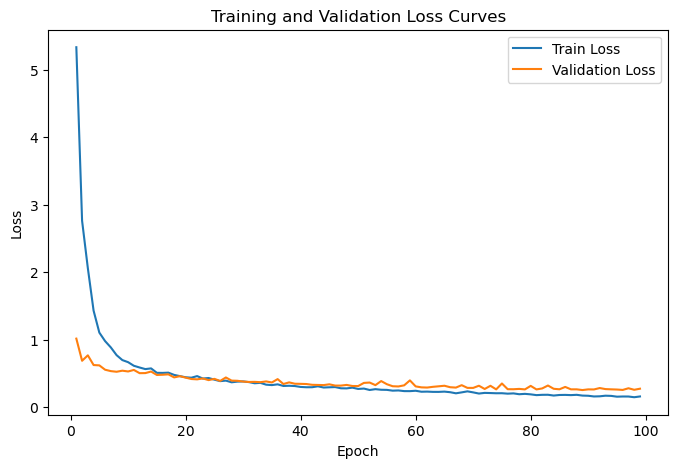

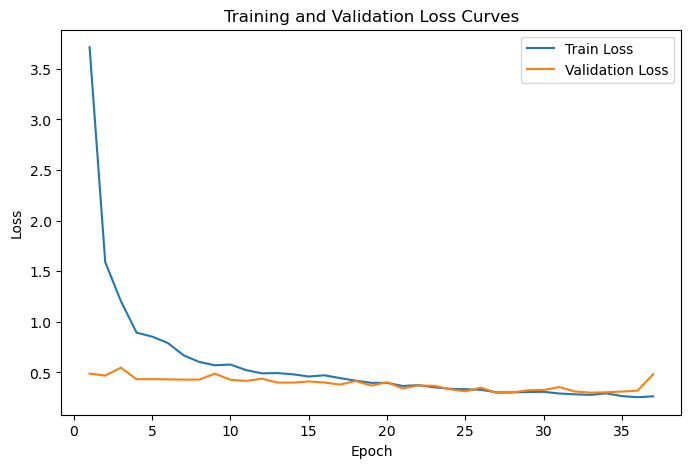

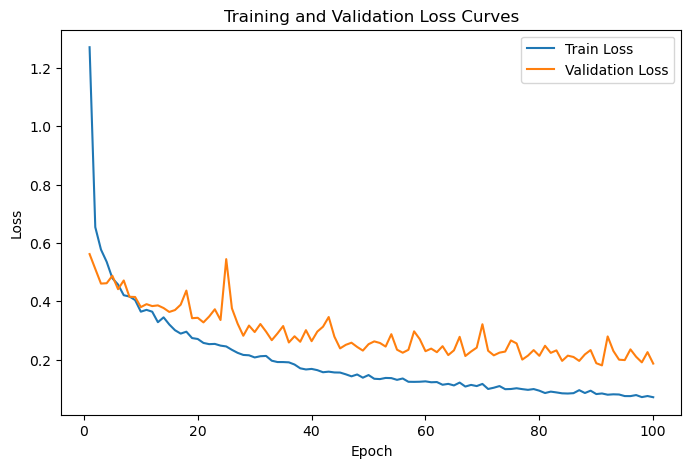

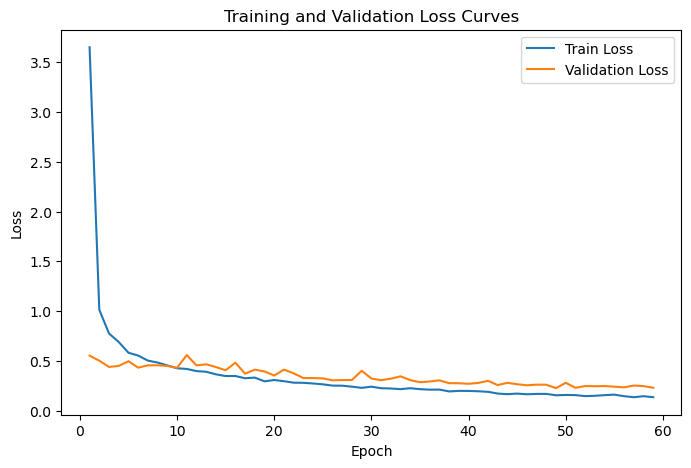

In [141]:
input_dim = data_list[0].x.shape[1]
edge_dim = data_list[0].edge_attr.shape[1]
global_feat_dim = len(descriptor_functions)

param_grid = {
    # 'lr': [1e-4, 3e-4, 1e-3, 3e-3, 1e-2],  # Learning rates spanning two orders of magnitude
    # 'hidden_dim': [32, 64, 128, 256],      # Network width
    'lr': [1e-4, 3e-4],  # Learning rates spanning two orders of magnitude
    'hidden_dim': [64, 128],      # Network width
    # 'num_layers': [2, 3, 5],               # GIN depth - common sweet spots
    # 'dropout': [0.0, 0.2, 0.5],            # Regularisation via dropout
    # 'batch_size': [32, 64, 128],           # Mini-batch sizes
    # 'weight_decay': [0.0, 1e-5, 1e-4],     # L2 regularisation on weights
    # 'readout': ['sum', 'mean', 'max'],     # Different aggregation schemes (depends on your GIN implementation)
    # 'activation': ['relu', 'leakyrelu'],   # Activation function choice
}

best_model = None
best_loss = float('inf')
best_params = None

for lr, hidden_dim in itertools.product(param_grid['lr'], param_grid['hidden_dim']):
    print(f"\nTraining with lr={lr}, hidden_dim={hidden_dim}")
    params = {
    'lr': lr,
    'hidden_dim': hidden_dim,
    'input_dim': input_dim,
    'edge_dim': edge_dim,
    'global_feat_dim': global_feat_dim
}
    model = train_with_early_stopping(params)
    val_loss, _, _ = eval_epoch(model, val_loader, torch.nn.MSELoss())

    if val_loss < best_loss:
        best_loss = val_loss
        best_model = model
        best_params = params

print(f"Best params: {best_params}")

## Evaluation


Best params: {'lr': 0.0003, 'hidden_dim': 64, 'input_dim': 42, 'edge_dim': 9, 'global_feat_dim': 17}

RMSE: 0.4279
MAE: 0.2759
R²: 0.6925


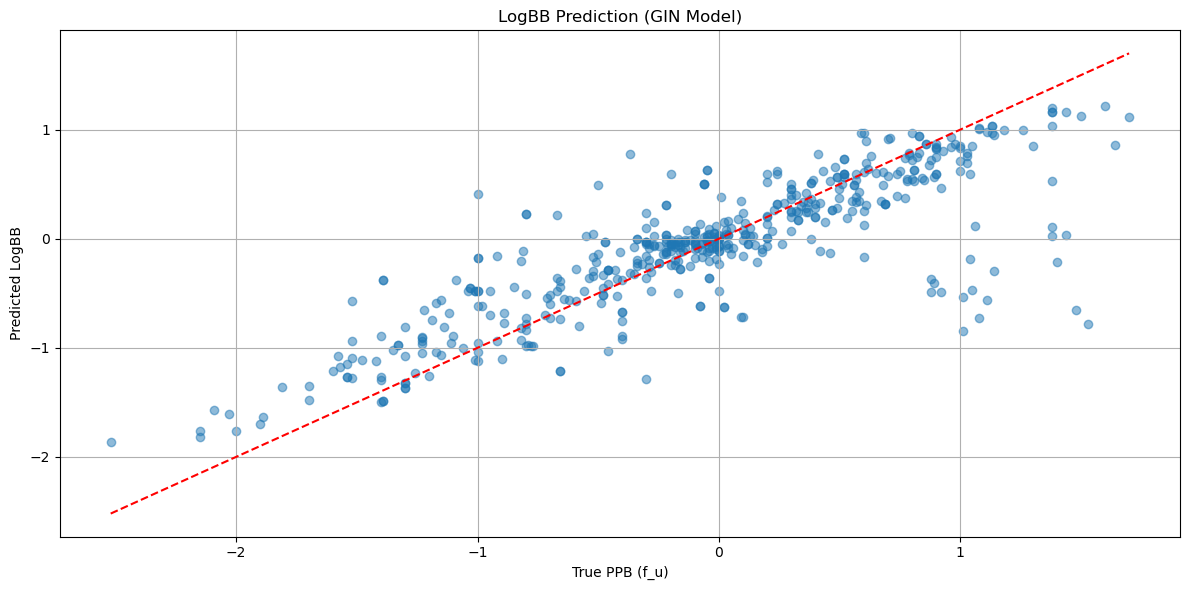

In [142]:
print(f"\nBest params: {best_params}")

y_true = []
y_pred = []

with torch.no_grad():
    for batch in val_loader:
        batch = batch.to(device)
        pred = best_model(batch)
        y_true.extend(batch.y.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"\nRMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

plt.figure(figsize=(12, 6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
plt.xlabel("True PPB (f_u)")
plt.ylabel("Predicted LogBB")
plt.title("LogBB Prediction (GIN Model)")
plt.grid(True)
plt.tight_layout()
plt.savefig("_images/true_vs_predicted_LogBB.png", dpi=300)
plt.show()

Both training and validation loss steadily decrease the curves track closely, indicative of no strong overfitting and validation loss stability towards the end suggests the model generalizes well on unseen data. There's some scatter at the lower-end (< 10% f_u). The results are reasonable but we should check with some CV. 

In [30]:
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Draw
import math
import os

output_dir = "_images"
os.makedirs(output_dir, exist_ok=True)

val_smiles = [d.smiles for d in val_list]

# Filter indices with error > 5 * true
outlier_indices = [i for i, (t, p) in enumerate(zip(y_true, y_pred)) if abs(p - t) > 5 * abs(t)]
print(f"Number of outliers: {len(outlier_indices)}")

mol_per_row = 5
img_size = (300, 300)
n_mols = len(outlier_indices)
n_rows = math.ceil(n_mols / mol_per_row)

fig, axs = plt.subplots(n_rows, mol_per_row, figsize=(mol_per_row * 3, n_rows * 3))
axs = axs.flatten()

for ax in axs:
    ax.axis('off')

for i, idx in enumerate(outlier_indices):
    smiles = val_smiles[idx]
    true_val = y_true[idx]
    pred_val = y_pred[idx]
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is not None:
        img = Draw.MolToImage(mol, size=img_size)
        axs[i].imshow(img)
        axs[i].axis('off')
        axs[i].set_title(f"T: {true_val:.2f}\nP: {pred_val:.2f}\nΔ: {abs(pred_val - true_val):.2f}", fontsize=8)
    else:
        axs[i].text(0.5, 0.5, "Invalid SMILES", ha='center', va='center')
        axs[i].axis('off')

plt.tight_layout()

# Save to disk
grid_image_path = os.path.join(output_dir, "5x_outliers_grid.png")
plt.savefig(grid_image_path, dpi=300)
plt.close()
print(f"Saved outlier grid image to: {grid_image_path}")


Number of outliers: 63
Saved outlier grid image to: _images/5x_outliers_grid.png


**63** proper outliers. Seems that the hardest to predict are those that are highly bound (f_u < 1%). Worth investing some time in getting these right, but for now given it's predicting compounds > 5% okay, we'll stick with the model.

Let's see if there's a systemtic bias in the CV.

### Cross-validation run.

In [32]:
def train_fold(train_idx, val_idx, params):
    train_subset = [data_list[i] for i in train_idx]
    val_subset = [data_list[i] for i in val_idx]

    train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, collate_fn=custom_collate)
    val_loader = DataLoader(val_subset, batch_size=32, shuffle=False, collate_fn=custom_collate)

    def train_epoch_fold(model, loader, optimizer, loss_fn):
        model.train()
        total_loss = 0
        for batch in loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch)
            loss = loss_fn(out, batch.y.to(device).float())
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        return total_loss / len(loader)

    def eval_epoch_fold(model, loader, loss_fn):
        model.eval()
        total_loss = 0
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for batch in loader:
                batch = batch.to(device)
                out = model(batch)
                loss = loss_fn(out, batch.y.to(device).float())
                total_loss += loss.item()
                all_preds.append(out.cpu())
                all_labels.append(batch.y.cpu())
        return total_loss / len(loader), torch.cat(all_preds), torch.cat(all_labels)

    model = GINRegressor(
        input_dim=params['input_dim'],
        hidden_dim=params['hidden_dim'],
        global_feat_dim=params.get('global_feat_dim', 0)
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])
    loss_fn = torch.nn.MSELoss()

    best_val_loss = float('inf')
    patience = 10
    counter = 0

    for epoch in range(100):
        train_loss = train_epoch_fold(model, train_loader, optimizer, loss_fn)
        val_loss, _, _ = eval_epoch_fold(model, val_loader, loss_fn)

        print(f"Epoch {epoch+1} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), f'best_model_fold_{fold}.pth')
        else:
            counter += 1

        if counter >= patience:
            print("Early stopping triggered.")
            break

    model.load_state_dict(torch.load(f'best_model_fold_{fold}.pth'))
    return model, val_loss

# Now run k-fold CV:

kf = KFold(n_splits=5, shuffle=True, random_state=42)
input_dim = data_list[0].x.shape[1]
global_feat_dim = len(descriptor_functions)

param_grid = {
    'lr': 0.0003,
    'hidden_dim': 256,
    'input_dim': input_dim,
    'global_feat_dim': global_feat_dim
}

val_losses = []

for fold, (train_idx, val_idx) in enumerate(kf.split(data_list)):
    print(f"\nFold {fold+1}")
    model, val_loss = train_fold(train_idx, val_idx, param_grid)
    val_losses.append(val_loss)

print(f"\nAverage validation loss across folds: {sum(val_losses)/len(val_losses):.4f}")


Fold 1
Epoch 1 | Train: 1248.4164 | Val: 1374.0641
Epoch 2 | Train: 908.6288 | Val: 1400.6762
Epoch 3 | Train: 762.6872 | Val: 835.7296
Epoch 4 | Train: 682.1862 | Val: 678.2941
Epoch 5 | Train: 616.0880 | Val: 752.7783
Epoch 6 | Train: 559.1787 | Val: 553.6348
Epoch 7 | Train: 493.6980 | Val: 481.6333
Epoch 8 | Train: 468.9267 | Val: 466.4667
Epoch 9 | Train: 452.9287 | Val: 595.3486
Epoch 10 | Train: 413.5548 | Val: 572.6354
Epoch 11 | Train: 390.4454 | Val: 487.6101
Epoch 12 | Train: 367.3027 | Val: 349.6601
Epoch 13 | Train: 347.7152 | Val: 396.4394
Epoch 14 | Train: 353.5417 | Val: 347.8274
Epoch 15 | Train: 308.3503 | Val: 369.8305
Epoch 16 | Train: 299.6066 | Val: 370.7656
Epoch 17 | Train: 291.6391 | Val: 368.2653
Epoch 18 | Train: 288.9224 | Val: 343.1665
Epoch 19 | Train: 288.4505 | Val: 307.5432
Epoch 20 | Train: 279.6834 | Val: 264.2521
Epoch 21 | Train: 260.5104 | Val: 337.2993
Epoch 22 | Train: 260.7839 | Val: 257.0838
Epoch 23 | Train: 245.5819 | Val: 240.0552
Epoch 24 

Final check; before saving, let's look at any significant differences in L2 weight norms between each model generated in CV.

In [ ]:
# Setup
FOLD_PATHS = [f'best_model_fold_{i}.pth' for i in range(5)]
DEVICE = 'cuda'  # or 'cuda' if available
sns.set(style='whitegrid')

# Need to redefine the model here
class GINRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, global_feat_dim=0, n_layers=3, dropout=0.2):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(n_layers):
            in_dim = input_dim if i == 0 else hidden_dim
            mlp = nn.Sequential(
                nn.Linear(in_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            )
            self.layers.append(GINConv(mlp))

        self.bns = nn.ModuleList([nn.BatchNorm1d(hidden_dim) for _ in range(n_layers)])

        self.readout = nn.Sequential(
            nn.Linear(hidden_dim + global_feat_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        for conv, bn in zip(self.layers, self.bns):
            x = F.relu(bn(conv(x, edge_index)))
        x = global_add_pool(x, batch)  # try add instead of mean
        if hasattr(data, "global_features"):
            x = torch.cat([x, data.global_features.to(x.device)], dim=1)
        return self.readout(x).squeeze(1)


# Use the best parameters from teh grid search in training
# Best params: {'lr': 0.0003, 'hidden_dim': 256, 'input_dim': 36, 'global_feat_dim': 17}
params = {
    'input_dim': 36,         # Replace with your actual input_dim
    'hidden_dim': 256,        # Replace with your actual hidden_dim
    'global_feat_dim': 17     # Replace if you used global features
}

# Load each model from disk
models = []
for fold_path in FOLD_PATHS:
    model = GINRegressor(
        input_dim=params['input_dim'],
        hidden_dim=params['hidden_dim'],
        global_feat_dim=params.get('global_feat_dim', 0)
    ).to(DEVICE)
    state_dict = torch.load(fold_path, map_location=DEVICE)
    model.load_state_dict(state_dict)
    models.append(model)

# Extract all weights from each model
def get_all_weights(model: torch.nn.Module) -> np.ndarray:
    weights = []
    for name, param in model.named_parameters():
        if param.requires_grad:
            weights.append(param.detach().cpu().numpy().flatten())
    return np.concatenate(weights)

def get_model():
    return GINRegressor(
        input_dim=36,
        hidden_dim=256,
        global_feat_dim=17  # Optional
    )
    return model

# Load models and compute L2 norms per layer
def get_weight_norms(model):
    norms = {}
    for name, param in model.named_parameters():
        if param.requires_grad:
            norms[name] = param.data.norm(2).item()
    return norms

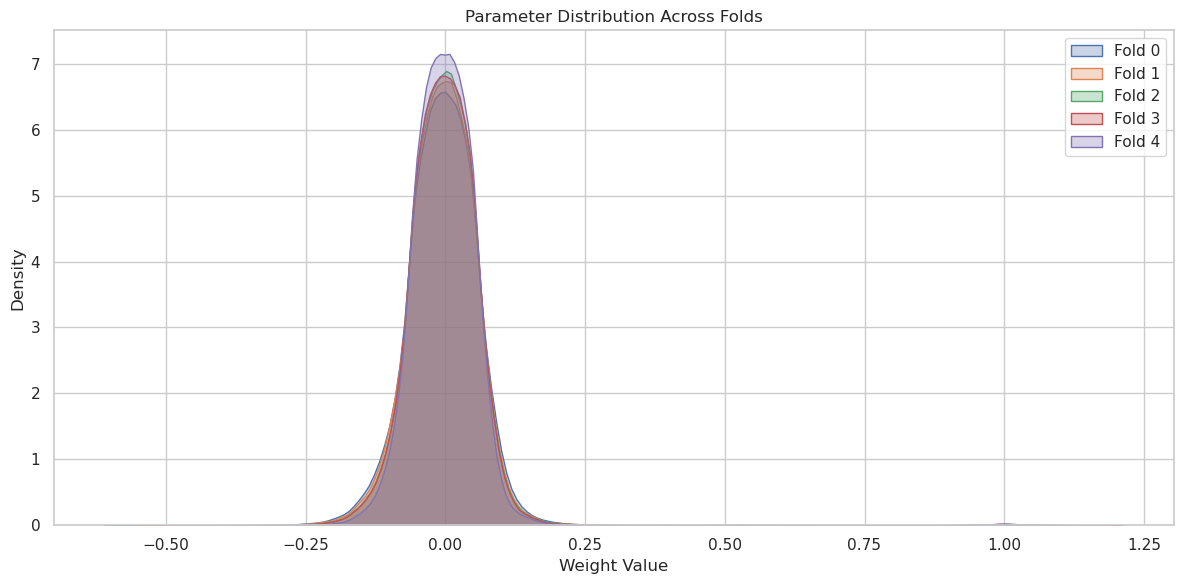

In [37]:
# Histogram showing variance of aggregated weights 
# Collect weights and plot kdes
all_weights = {f'Fold {i}': get_all_weights(model) for i, model in enumerate(models)}

plt.figure(figsize=(12, 6))
for fold, weights in all_weights.items():
    sns.kdeplot(weights, label=fold, fill=True, alpha=0.3)
plt.title('Parameter Distribution Across Folds')
plt.xlabel('Weight Value')
plt.ylabel('Density')
plt.legend()
plt.savefig("_images/parameter_distribution.png", dpi=300)
plt.tight_layout()
plt.show()

Seems all parameters vary tightly. How about a breakdown of each parameter across all folds?

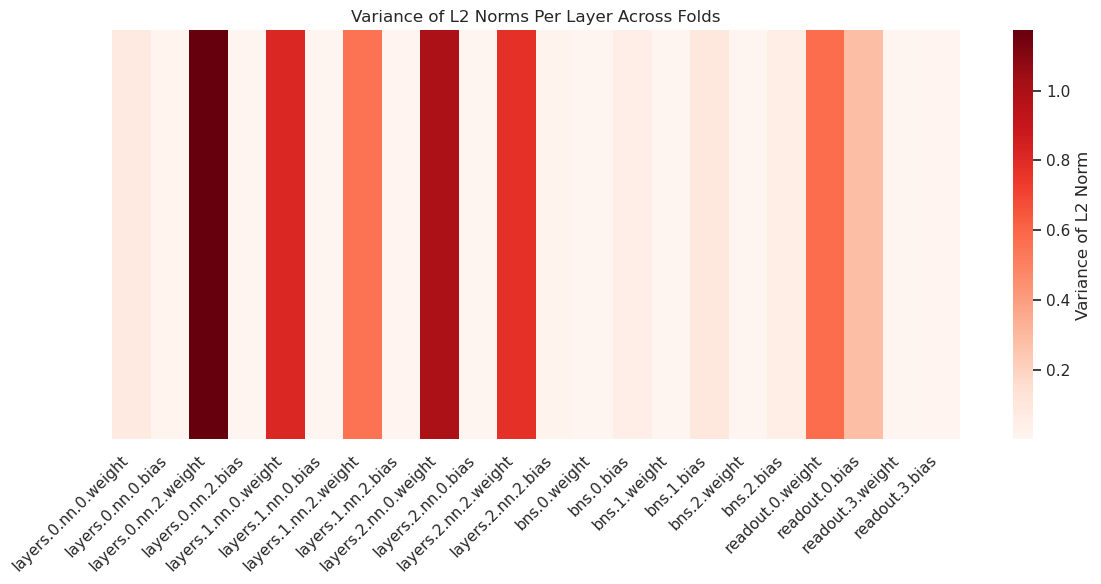

In [43]:
# Now let's have a look at each weight across all folds
# Collect norms for each model
norms_per_fold = {f'Fold {i}': get_weight_norms(model) for i, model in enumerate(models)}

df_norms = pd.DataFrame(norms_per_fold)

# Compute variance across folds per parameter
df_variance = df_norms.var(axis=1)

plt.figure(figsize=(12, 6))
sns.heatmap(df_variance.to_frame().T, cmap='Reds', cbar_kws={'label': 'Variance of L2 Norm'})
plt.yticks([])
plt.xticks(rotation=45, ha='right')
plt.title('Variance of L2 Norms Per Layer Across Folds')
plt.tight_layout()
plt.savefig("_images/l2_norm_variance.png", dpi=300)
plt.show()

Some evidence of variance over all folds in a few metrics. Let's show a breakdown by fold to locate how many folds are affected and by how much.

<Figure size 1400x600 with 0 Axes>

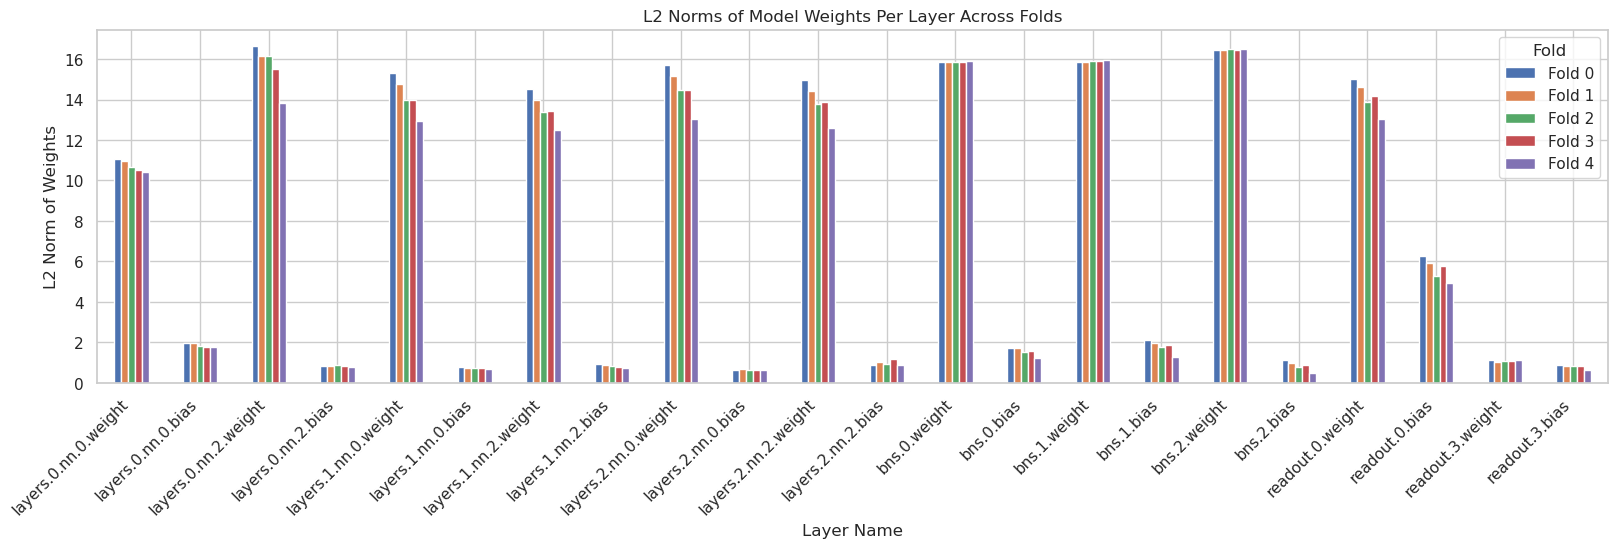

In [47]:
# Finally, let's look at the metrics per fold
num_folds = 5  
norms_per_fold = []

# TODO refactor so this isn't having to be loaded twice

for fold in range(num_folds):
    model = get_model()
    state_dict = torch.load(f'best_model_fold_{fold}.pth', map_location='cpu')
    model.load_state_dict(state_dict)
    model.eval()
    
    norms = get_weight_norms(model)
    norms_per_fold.append(norms)

df = pd.DataFrame(norms_per_fold)
df.index = [f'Fold {i}' for i in range(num_folds)]

plt.figure(figsize=(14, 6))
df.T.plot(kind='bar', figsize=(16, 6))
plt.title('L2 Norms of Model Weights Per Layer Across Folds')
plt.xlabel('Layer Name')
plt.ylabel('L2 Norm of Weights')
plt.grid(True)
plt.legend(title='Fold')
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.savefig("_images/weight_norms_comparison.png", dpi=300)
plt.show()

Fold 4 tends to have slightly smaller L2 norms across many layers, it might indicate that this fold’s training data subset had slightly different scaling or feature distribution. 

The weight magnitudes confirm stable training and consistent representations across folds. The variance we saw earlier is not concerning - it represents minor shifts in weight-space, not meaningfully different learned mappings. So owe could, in principle, safely ensemble these models for improved uncertainty estimation, since they are independent but consistent learners.

In [ ]:
torch.save({
    "model_state_dict": model.state_dict(),
    "input_dim": input_dim,
    "hidden_dim": hidden_dim,
    "global_feat_dim": global_feat_dim
    }, "log_bb_gin.pt")

: 